In [195]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [196]:
LOG_DIR = Path("ProfilingLogs")
SUMMARY_PATH = LOG_DIR / "summary.csv"

plt.rcParams.update({
    "font.family": "monospace",
    "font.monospace": ["DejaVu Sans Mono"],
})


df = pd.read_csv(SUMMARY_PATH)

# --- Clean columns ---
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)

# --- Derived metrics ---
df["bottleneck_median_ms"] = np.maximum(
    df["median_cpu_ms"],
    df["median_gpu_ms"]
)

df["bottleneck_p95_ms"] = np.maximum(
    df["p95_cpu_ms"],
    df["p95_gpu_ms"]
)

df["bottleneck_p99_ms"] = np.maximum(
    df["p99_cpu_ms"],
    df["p99_gpu_ms"]
)

# --- Parsing helpers ---
def parse_method_family(name):
    if name.startswith("AreaScaling"): return "AreaScaling"
    if name.startswith("BBoxCountScaling") or name.startswith("CountScaling"): return "CountScaling"
    if name.startswith("BBoxAreaScaling"): return "BBoxAreaScaling"
    if name.startswith("CoverageScaling"): return "CoverageScaling"
    if name.startswith("OverlapScaling"): return "OverlapScaling"
    if name.startswith("OcclusionScaling"): return "OcclusionScaling"
    if name.startswith("StackedStylesScaling"): return "StackedStylesScaling"
    return "Other"

def parse_shader_variant(name):
    return "Heavy" if "Heavy" in name else "Default"

def parse_style_variant(name):
    if "SameStyle" in name: return "SameStyle"
    if "RandomSingleStyle" in name: return "RandomSingleStyle"
    return None

def parse_merge_label(name):
    if "_NoMerge_" in name or name.endswith("_NoMerge"):
        return "NoMerge"
    if "_Merge_" in name or name.endswith("_Merge"):
        return "Merge"
    return None

def parse_object_variant(name):
    m = re.search(r"Obj(\d+)", name)
    return f"Obj{m.group(1)}" if m else None

def parse_coverage_variant(name):
    m = re.search(r"Cov(\d+)", name)
    return f"Cov{m.group(1)}" if m else None

# --- Apply parsing ---
df["method_family"] = df["test_name"].apply(parse_method_family)
df["shader_variant"] = df["test_name"].apply(parse_shader_variant)
df["style_variant"] = df["test_name"].apply(parse_style_variant)
df["merge_label"] = df["test_name"].apply(parse_merge_label)
df["object_variant"] = df["test_name"].apply(parse_object_variant)
df["coverage_variant"] = df["test_name"].apply(parse_coverage_variant)

# --- Core data views ---
method_df = df[
    df["render_mode"].isin(["Fullscreen", "CPU", "GPU", "Tiling"]) &
    df["merge_label"].isna()
].copy()

merge_ablation_df = df[
    df["render_mode"].isin(["CPU", "GPU"]) &
    df["merge_label"].isin(["Merge", "NoMerge"])
].copy()

tiling_df = df[
    (df["render_mode"] == "Tiling") &
    df["merge_label"].isna()
].copy()

# --- Generic filter ---
def select_runs(data, **filters):
    out = data.copy()
    for col, value in filters.items():
        if value is None or col not in out.columns:
            continue
        if isinstance(value, (list, tuple, set)):
            out = out[out[col].isin(value)]
        else:
            out = out[out[col] == value]
    return out

print("Loaded:", len(df), "rows")

Loaded: 1844 rows


In [197]:
STYLE_MAP = {
    "Fullscreen": {"color": "black", "linestyle": "-", "marker": "o"},
    "CPU": {"color": "tab:blue", "linestyle": "-", "marker": "o"},
    "GPU": {"color": "tab:orange", "linestyle": "-", "marker": "s"},
    "Tiling": {"color": "tab:green", "linestyle": "-", "marker": "^"},

    "CPU NoMerge": {"color": "tab:blue", "linestyle": "--", "marker": "o"},
    "CPU Merge": {"color": "tab:blue", "linestyle": "-", "marker": "o"},
    "GPU NoMerge": {"color": "tab:orange", "linestyle": "--", "marker": "s"},
    "GPU Merge": {"color": "tab:orange", "linestyle": "-", "marker": "s"},

    "Tiling 8": {"color": "tab:green", "linestyle": ":", "marker": "o"},
    "Tiling 16": {"color": "tab:green", "linestyle": "--", "marker": "s"},
    "Tiling 32": {"color": "tab:green", "linestyle": "-.", "marker": "^"},
    "Tiling 64": {"color": "tab:green", "linestyle": "-", "marker": "D"},
}

METRICS = {
    "cpu": ("median_cpu_ms",  "CPU frame time (ms)"),
    "gpu": ("median_gpu_ms",  "GPU frame time (ms)"),
    "bottleneck": ("bottleneck_median_ms", "Bottleneck frame time (ms)"),
}

TAIL_METRICS = {
    "p95_cpu": ("p95_cpu_ms", "P95 CPU frame time (ms)"),
    "p99_cpu": ("p99_cpu_ms", "P99 CPU frame time (ms)"),
    "p95_gpu": ("p95_gpu_ms", "P95 GPU frame time (ms)"),
    "p99_gpu": ("p99_gpu_ms", "P99 GPU frame time (ms)"),
    "p95_bottleneck": ("bottleneck_p95_ms", "P95 bottleneck frame time (ms)"),
    "p99_bottleneck": ("bottleneck_p99_ms", "P99 bottleneck frame time (ms)"),
}


def get_style(label):
    return STYLE_MAP.get(label, {"color": "gray", "linestyle": "-", "marker": "o"})

def get_label_col(kind):
    if kind == "method":
        return "render_mode"
    if kind == "merge":
        return "merge_method_label"
    if kind == "tiling":
        return "tiling_label"
    raise ValueError(f"Unknown plot kind: {kind}")

def add_plot_labels(df):
    df = df.copy()

    df["method_label"] = df["render_mode"].astype(str)

    if "merge_label" not in df.columns:
        if "merge" in df.columns:
            df["merge_label"] = df["merge"].map({
                False: "NoMerge",
                True: "Merge",
                "False": "NoMerge",
                "True": "Merge",
                "false": "NoMerge",
                "true": "Merge",
            })
        else:
            df["merge_label"] = None

    df["merge_method_label"] = (
        df["render_mode"].astype(str) + " " + df["merge_label"].astype(str)
    )

    if "tile_size" in df.columns:
        df["tiling_label"] = "Tiling " + df["tile_size"].astype(str)
    else:
        df["tiling_label"] = df["render_mode"].astype(str)

    if "occlusion_label" not in df.columns:
        if "occlusion" in df.columns:
            df["occlusion_label"] = df["occlusion"].map({
                False: "NoOcclusion",
                True: "Occlusion",
                "False": "NoOcclusion",
                "True": "Occlusion",
                "false": "NoOcclusion",
                "true": "Occlusion",
            })
        else:
            df["occlusion_label"] = None

    df["occlusion_method_label"] = (
        df["render_mode"].astype(str) + " " + df["occlusion_label"].astype(str)
    )

    return df

In [198]:
def _apply_k_filter(data, K_filter=None):
    data = data.copy()

    is_stacked = (
        "method_family" in data.columns
        and data["method_family"].eq("StackedStylesScaling").any()
    )

    k_col = "K" if "K" in data.columns else "k" if "k" in data.columns else None

    if K_filter is not None and not is_stacked:
        if k_col is None:
            print("Warning: no K/k column found, skipping K filter.")
        elif isinstance(K_filter, (list, tuple, set)):
            data = data[data[k_col].isin(K_filter)]
        else:
            data = data[data[k_col] == K_filter]

    return data


def plot_metric_line(
    data,
    x_col="value",
    x_label=None,
    plot_kind="method",
    metric="bottleneck",
    ax=None,
    title=None,
    K_filter=None,
):
    data = _apply_k_filter(data, K_filter)

    if data.empty:
        print("No data after filtering.")
        return ax

    data = add_plot_labels(data)
    label_col = get_label_col(plot_kind)

    median_col, ylabel = METRICS[metric]

    if x_col not in data.columns:
        print(f"Column '{x_col}' not found.")
        return ax

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    for label, line_df in data.groupby(label_col):
        line_df = line_df.sort_values(x_col)
        style = get_style(label)

        ax.plot(
            line_df[x_col].values,
            line_df[median_col].values,
            label=label,
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
        )

    ax.axhline(16.67, linestyle="--", linewidth=1)
    ax.axhline(33.33, linestyle="--", linewidth=1)

    ax.text(0.99, 16.67, "60 FPS", transform=ax.get_yaxis_transform(), ha="right")
    ax.text(0.99, 33.33, "30 FPS", transform=ax.get_yaxis_transform(), ha="right")

    ax.set_title(title or metric.upper())
    ax.set_xlabel(x_label or x_col)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()

    return ax


def plot_metric_lines_all3(
    data,
    x_col="value",
    x_label=None,
    plot_kind="method",
    title=None,
    K_filter=None,
):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    for ax, metric in zip(axes, ["cpu", "gpu", "bottleneck"]):
        plot_metric_line(
            data,
            x_col=x_col,
            x_label=x_label,
            plot_kind=plot_kind,
            metric=metric,
            ax=ax,
            title=metric.upper(),
            K_filter=K_filter,
        )

    if title:
        fig.suptitle(title, y=1.05)

    plt.tight_layout()
    plt.show()

def plot_tail_grouped_bar(
    data,
    metric="bottleneck",
    x_col="value",
    x_label=None,
    plot_kind="method",
    ax=None,
    title=None,
    K_filter=None,
):
    data = _apply_k_filter(data, K_filter)

    if data.empty:
        print("No data after filtering.")
        return ax

    data = add_plot_labels(data)
    label_col = get_label_col(plot_kind)

    tail_cols = {
        "cpu": ("p95_cpu_ms", "p99_cpu_ms", "CPU frame time (ms)"),
        "gpu": ("p95_gpu_ms", "p99_gpu_ms", "GPU frame time (ms)"),
        "bottleneck": ("bottleneck_p95_ms", "bottleneck_p99_ms", "Bottleneck frame time (ms)"),
    }

    if metric not in tail_cols:
        raise ValueError(f"Unknown metric: {metric}")

    p95_col, p99_col, ylabel = tail_cols[metric]

    if p95_col not in data.columns or p99_col not in data.columns:
        print(f"Missing columns for {metric}: {p95_col}, {p99_col}")
        return ax

    grouped = (
        data
        .groupby([x_col, label_col], as_index=False)[[p95_col, p99_col]]
        .median()
        .sort_values([x_col, label_col])
    )

    x_values = sorted(grouped[x_col].unique())
    labels = list(grouped[label_col].dropna().unique())

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(x_values))
    width = 0.8 / max(len(labels), 1)

    for i, label in enumerate(labels):
        line_df = grouped[grouped[label_col] == label]

        p95_lookup = dict(zip(line_df[x_col], line_df[p95_col]))
        p99_lookup = dict(zip(line_df[x_col], line_df[p99_col]))

        p95_vals = np.array([p95_lookup.get(v, np.nan) for v in x_values])
        p99_vals = np.array([p99_lookup.get(v, np.nan) for v in x_values])
        p99_extra = np.maximum(p99_vals - p95_vals, 0)

        style = get_style(label)
        xpos = x + i * width - (width * (len(labels) - 1) / 2)

        ax.bar(
            xpos,
            p95_vals,
            width=width,
            color=style["color"],
            alpha=0.65,
            label=f"{label} P95",
        )

        ax.bar(
            xpos,
            p99_extra,
            width=width,
            bottom=p95_vals,
            color=style["color"],
            hatch="////",
            alpha=1.0,
            label=f"{label} P99 tail",
        )

    ax.axhline(16.67, linestyle="--", linewidth=1)
    ax.axhline(33.33, linestyle="--", linewidth=1)

    ax.text(0.99, 16.67, "60 FPS", transform=ax.get_yaxis_transform(), ha="right", va="bottom")
    ax.text(0.99, 33.33, "30 FPS", transform=ax.get_yaxis_transform(), ha="right", va="bottom")

    ax.set_xticks(x)
    ax.set_xticklabels(x_values)
    ax.set_title(title or metric.upper())
    ax.set_xlabel(x_label or x_col)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.3)

    return ax


def plot_tail_grouped_bars_all(
    data,
    x_col="value",
    x_label=None,
    plot_kind="method",
    title=None,
    K_filter=None,
):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    for ax, metric in zip(axes, ["cpu", "gpu", "bottleneck"]):
        plot_tail_grouped_bar(
            data,
            metric=metric,
            x_col=x_col,
            x_label=x_label,
            plot_kind=plot_kind,
            ax=ax,
            title=metric.upper(),
            K_filter=K_filter,
        )

    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    if title:
        fig.suptitle(title, y=1.08)

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=min(len(labels), 6),
        bbox_to_anchor=(0.5, 1.0),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

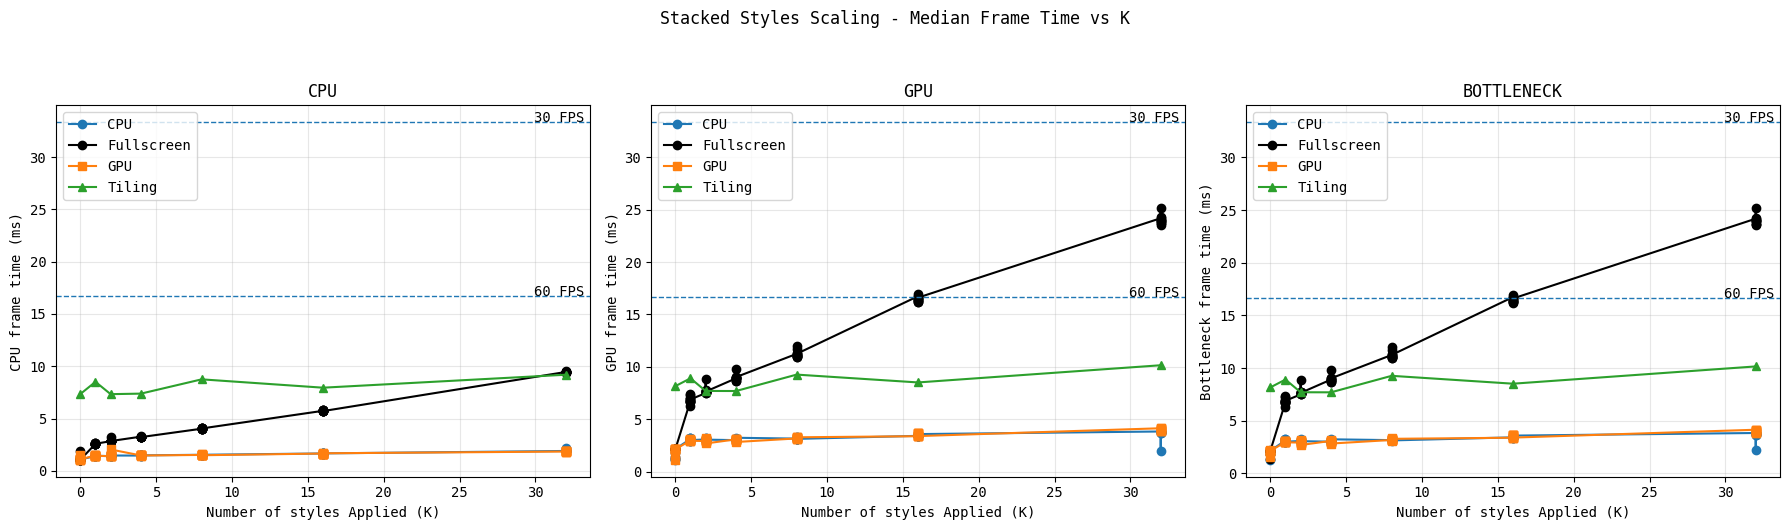

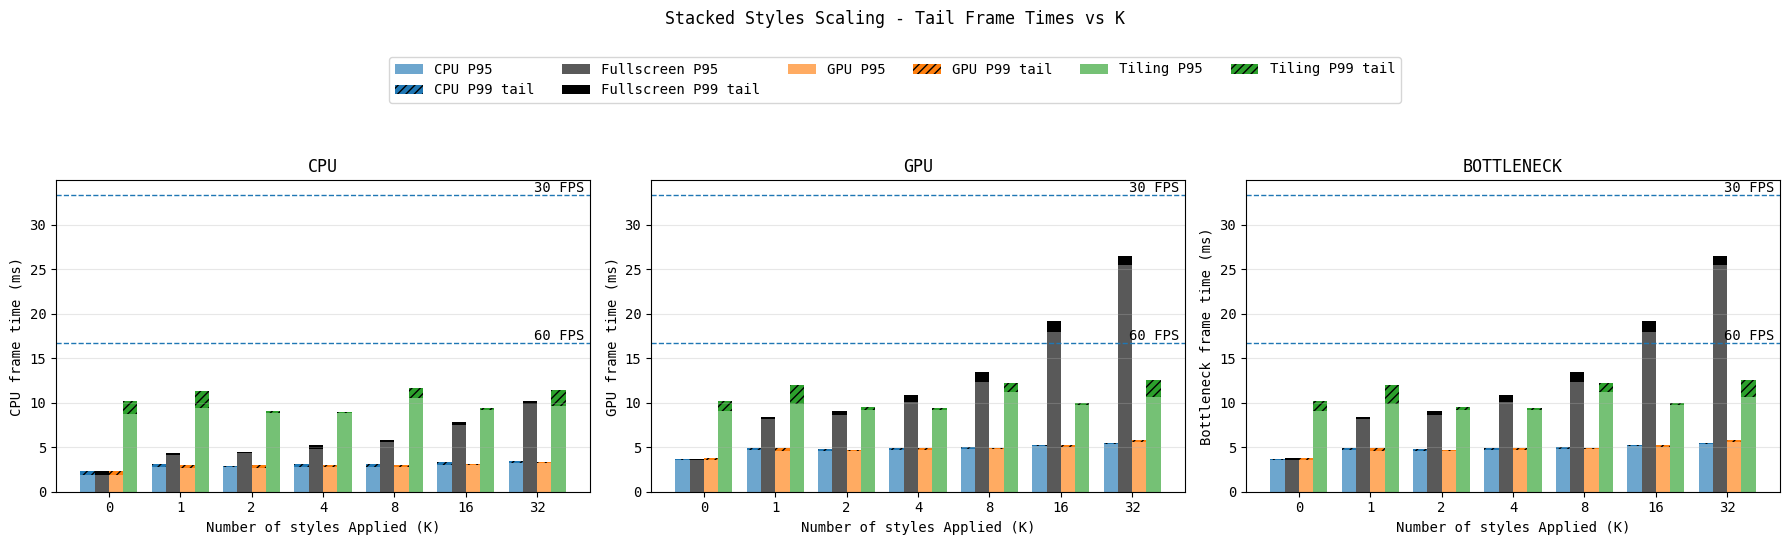

In [199]:
stacked_styles_df = select_runs(
    method_df,
    method_family="StackedStylesScaling",
)

plot_metric_lines_all3(
    stacked_styles_df,
    plot_kind="method",
    title="Stacked Styles Scaling - Median Frame Time vs K",
    x_label="Number of styles Applied (K)",
)

plot_tail_grouped_bars_all(
    stacked_styles_df,
    plot_kind="method",
    title="Stacked Styles Scaling - Tail Frame Times vs K",
    x_label="Number of styles Applied (K)",
)

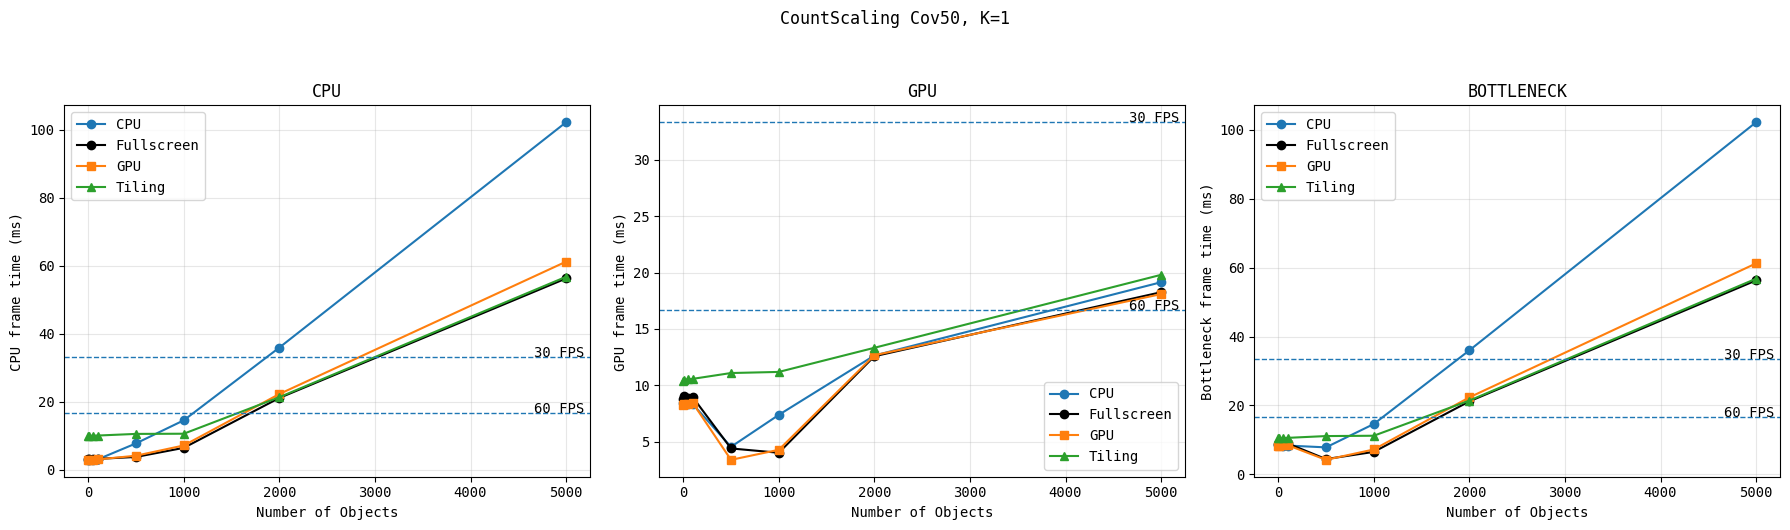

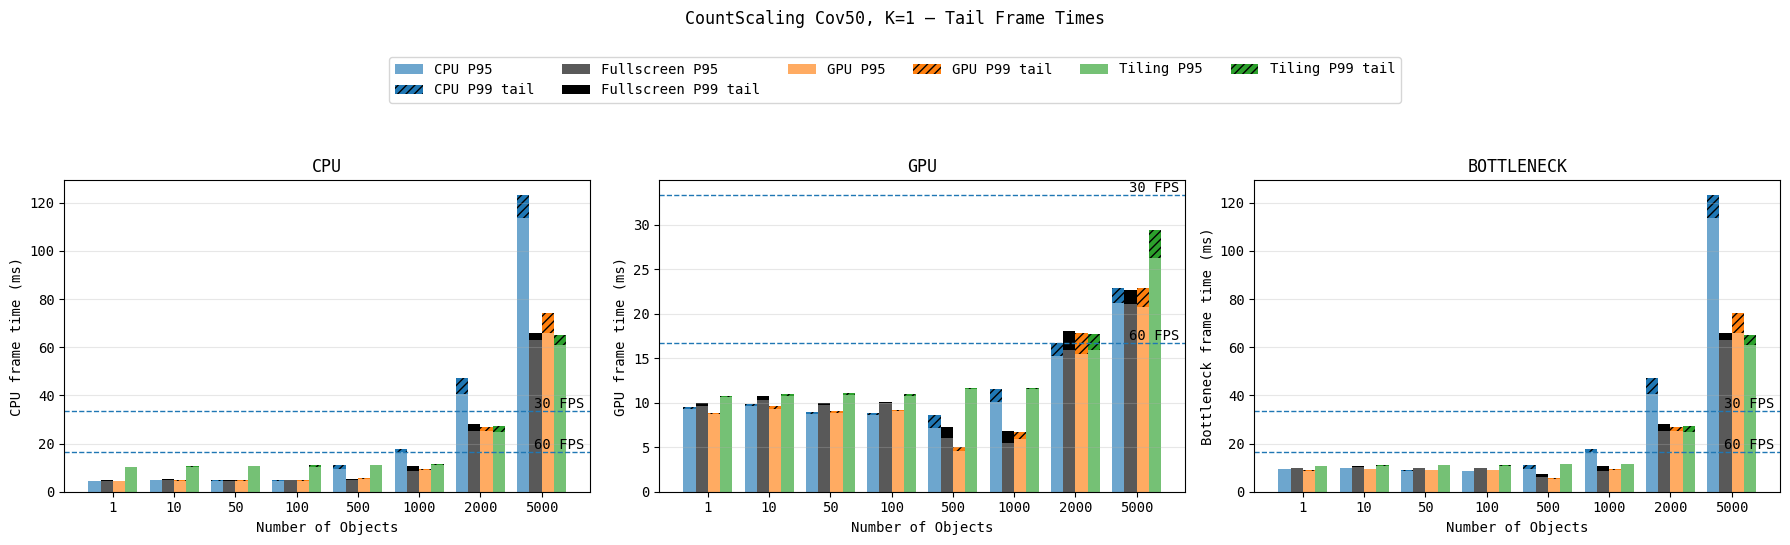

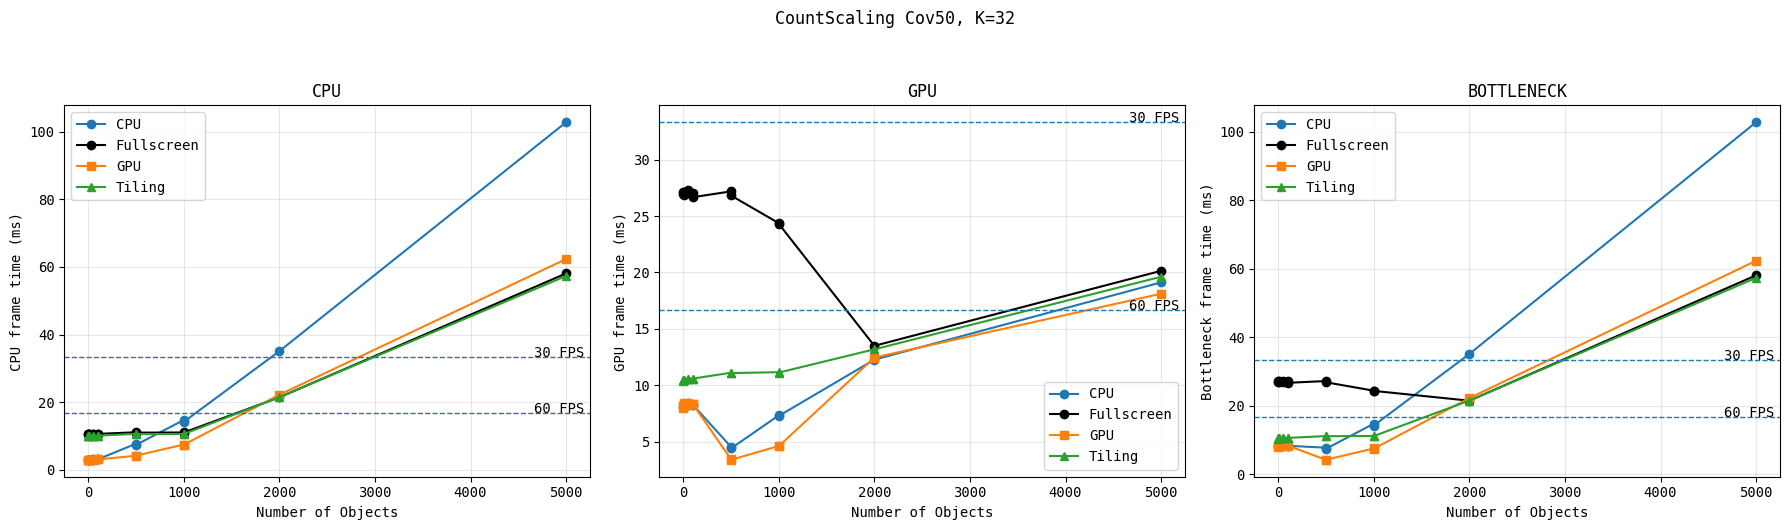

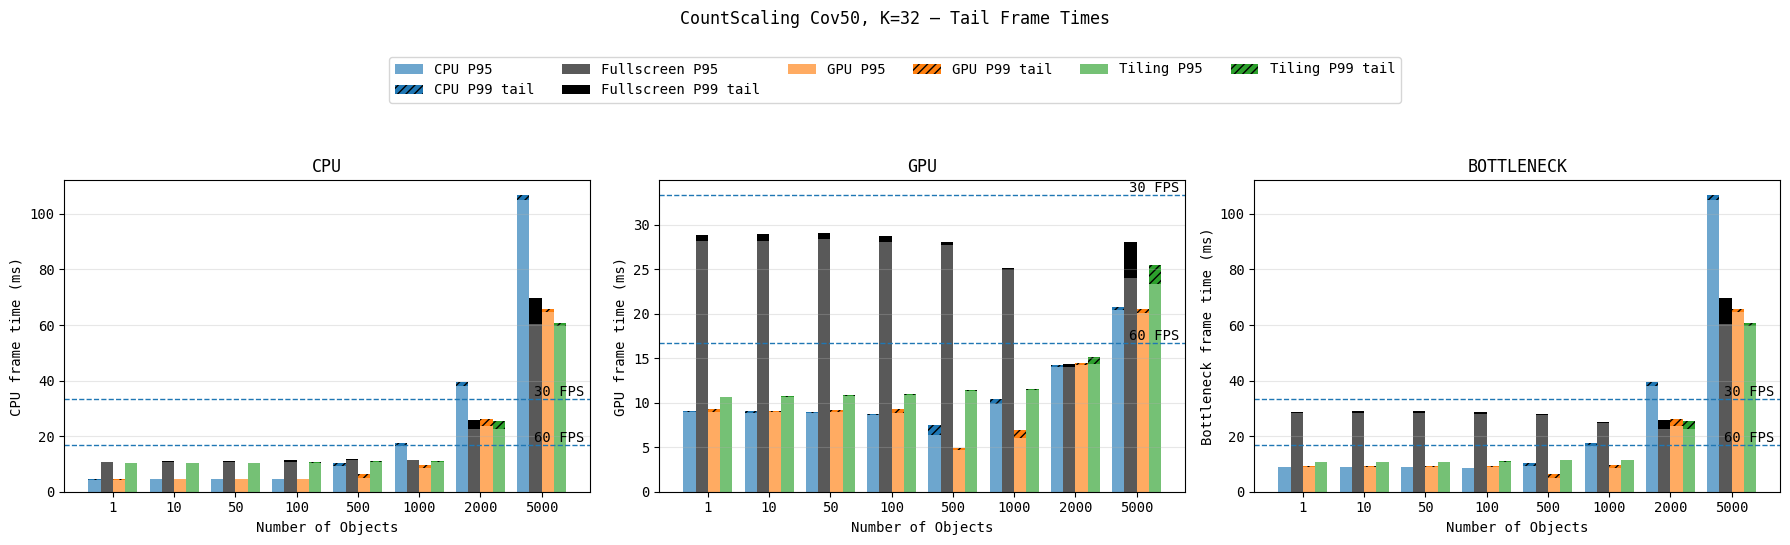

In [200]:
count_cov50 = select_runs(
    method_df,
    method_family="CountScaling",
    coverage_variant="Cov50"
)

plot_metric_lines_all3(
    count_cov50,
    plot_kind="method",
    K_filter=1,
    x_label="Number of Objects",
    title="CountScaling Cov50, K=1",
)

plot_tail_grouped_bars_all(
    count_cov50,
    plot_kind="method",
    K_filter=1,
    x_label="Number of Objects",
    title="CountScaling Cov50, K=1 — Tail Frame Times",
)

plot_metric_lines_all3(
    count_cov50,
    plot_kind="method",
    K_filter=32,
    x_label="Number of Objects",
    title="CountScaling Cov50, K=32",
)


plot_tail_grouped_bars_all(
    count_cov50,
    plot_kind="method",
    K_filter=32,
    x_label="Number of Objects",
    title="CountScaling Cov50, K=32 — Tail Frame Times",
)

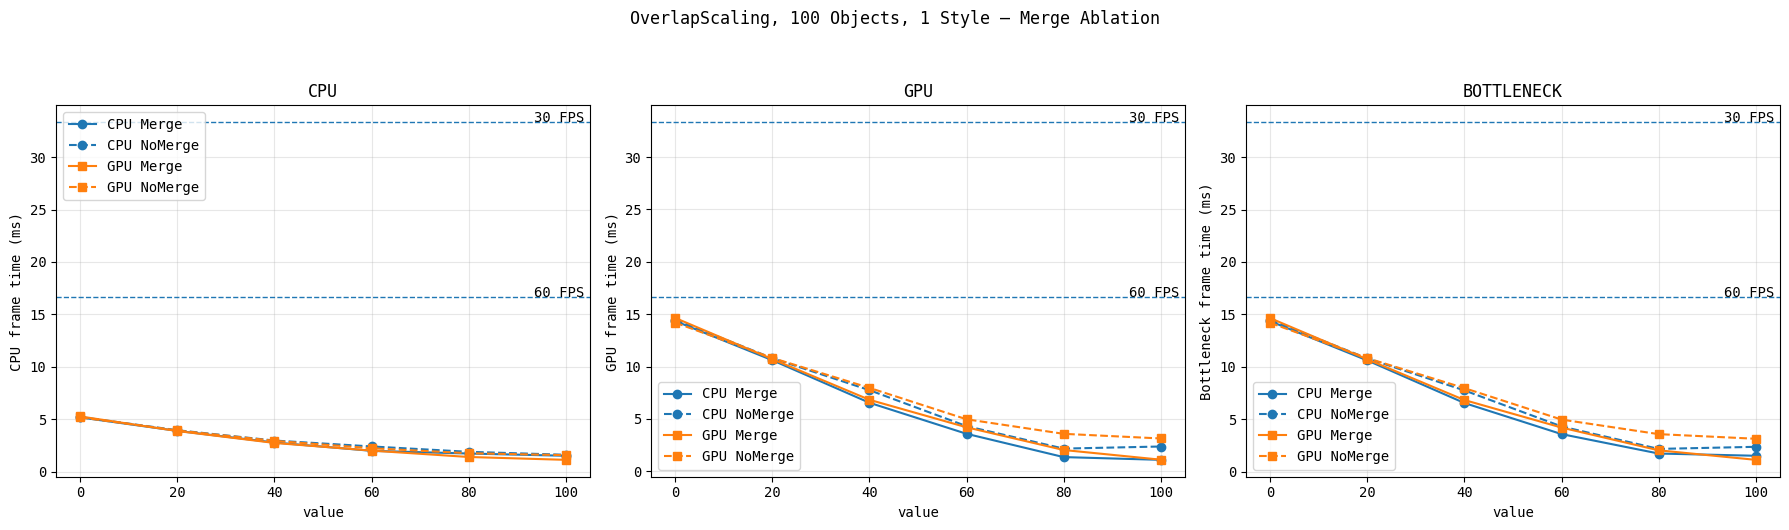

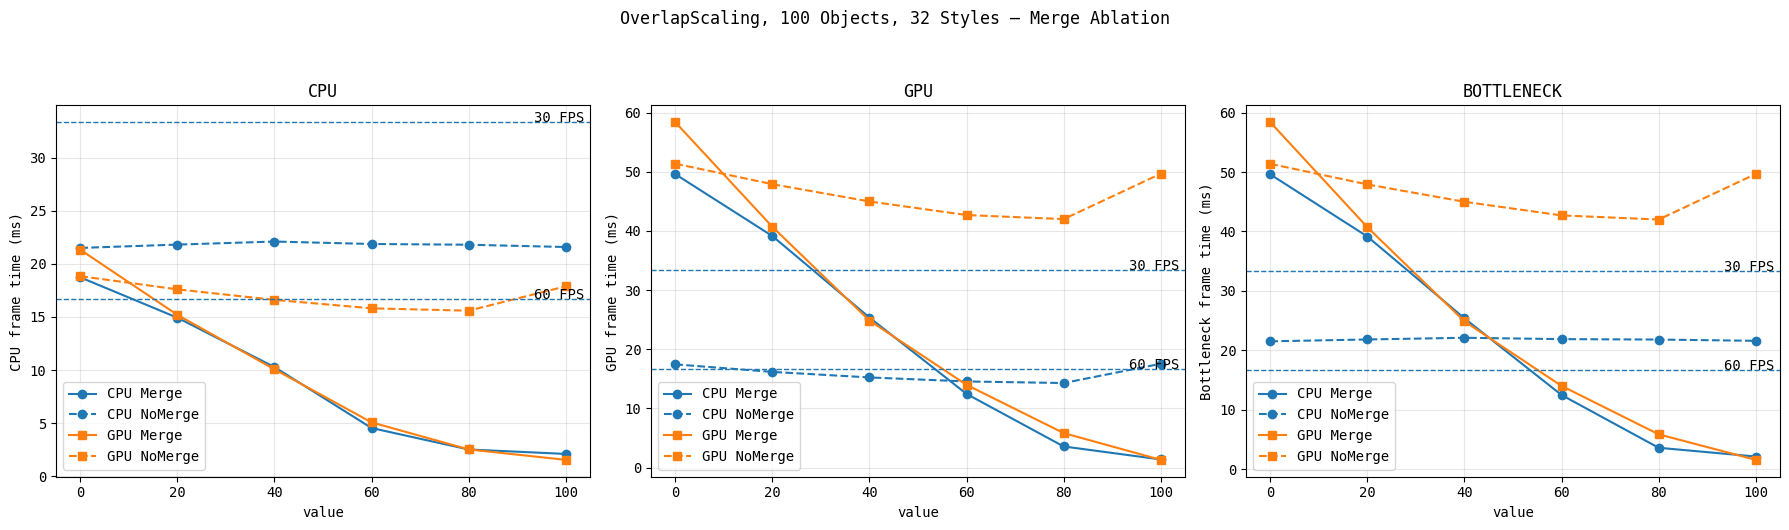

In [201]:

# 2. Overlap scaling, Obj100, default shader
overlap_merge_obj100 = select_runs(
    merge_ablation_df,
    method_family="OverlapScaling",
    object_variant="Obj100",
    shader_variant="Default"
)
plot_metric_lines_all3(
    overlap_merge_obj100,
    plot_kind="merge",
    K_filter=1,
    title="OverlapScaling, 100 Objects, 1 Style — Merge Ablation" 
)
plot_metric_lines_all3(
    overlap_merge_obj100,
    plot_kind="merge",
    K_filter=32,
    title="OverlapScaling, 100 Objects, 32 Styles — Merge Ablation" 
)